In [1]:
library(dplyr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
CA1_path <- "./03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass/CA1/"
CA1_files <- list.files(path = CA1_path, pattern = "\\.tmp$", full.names = TRUE)
CA1_files

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_FC_CT.mm10.tmp"     
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_FC_L2_3.mm10.tmp"   
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_FC_L4_Rorb.mm10.tmp"
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_FC_L5.mm10.tmp"     
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_FC_L6.mm10.tmp"     
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_FC_NP.mm10.tmp"     
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_HC_CA1.mm10.tmp"    
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_HC_CA23.mm10.tmp"   
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_HC_DG.mm10.tmp"     
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_In_CGE.mm10.tmp"    
[11] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_In_Pvalb.mm10.tmp"  
[12] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass/CA1//Paired-Tag_H3K9me3_In_Sst.mm10.tmp"

In [3]:
merged_CA1 <- NULL

In [4]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K9me3_FC_CT.mm10.tmp")

[1] "CT"

In [5]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K9me3_FC_L2_3.mm10.tmp")

[1] "L2_3"

In [6]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K9me3_HC_DG.mm10.tmp")
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K9me3_In_Pvalb.mm10.tmp")

[1] "DG"

[1] "Pvalb"

In [7]:
for (file in CA1_files) {

  base_name <- gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$", "\\2", basename(file))
  print(base_name)

  tmp_data <- read.table(file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)

  if (!is.null(merged_CA1)) {
    if (!identical(merged_CA1[, 1], tmp_data[, 1])) {
      stop(paste("The first column in file", file, "is not identical to the previous files!"))
    }
  }

  colnames(tmp_data)[2:3] <- paste(base_name, colnames(tmp_data)[2:3], sep = "_")

  if (is.null(merged_CA1)) {
    merged_CA1 <- tmp_data
  } else {
    merged_CA1 <- cbind(merged_CA1, tmp_data[, -1])
  }
}

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


In [8]:
merged_CA1

hyperDHMR,CT_signal_sum,CT_signal_sum_log10,L2_3_signal_sum,L2_3_signal_sum_log10,L4_Rorb_signal_sum,L4_Rorb_signal_sum_log10,L5_signal_sum,L5_signal_sum_log10,L6_signal_sum,⋯,CA23_signal_sum,CA23_signal_sum_log10,DG_signal_sum,DG_signal_sum_log10,CGE_signal_sum,CGE_signal_sum_log10,Pvalb_signal_sum,Pvalb_signal_sum_log10,Sst_signal_sum,Sst_signal_sum_log10
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,10.83740,1.073256,21.06100,1.343625,12.96060,1.144904,56.93740,1.762959,137.325200,⋯,16.09920,1.232976,22.94260,1.379171,47.66540,1.687220,154.25860,2.191056,0.00000,0.000000
chr1:4794017-4795017,216.74800,2.337954,84.24400,1.930664,129.60680,2.115966,142.34320,2.156377,68.662600,⋯,177.09160,2.250643,22.94260,1.379171,178.74540,2.254658,88.14780,1.950111,189.47360,2.279835
chr1:4947085-4948085,51.42328,1.719524,20.61346,1.334724,61.49843,1.795869,122.94898,2.093243,17.165600,⋯,195.92773,2.294307,149.17315,2.176592,66.67204,1.830409,200.20578,2.303640,31.57900,1.512938
chr1:5336791-5337791,260.09600,2.416800,173.75340,2.242426,116.64620,2.070578,42.70300,1.640511,120.159600,⋯,112.69460,2.055740,339.55200,2.532183,285.99200,2.457870,286.48000,2.458608,584.21000,2.767312
chr1:5745992-5746992,194.98570,2.292224,131.67352,2.122784,220.33200,2.345044,206.34106,2.316685,223.016672,⋯,184.88361,2.269241,412.45408,2.616427,309.54000,2.492118,506.32112,2.705283,220.79937,2.345960
chr1:5825616-5826616,275.96237,2.442421,193.67730,2.289315,134.58367,2.132207,82.16051,1.919917,141.307619,⋯,100.33041,2.005740,153.22024,2.188141,120.11699,2.083205,152.58393,2.186346,309.72664,2.492378
chr1:6177024-6178024,301.88542,2.481278,252.47928,2.403942,90.10269,1.959531,339.91587,2.532647,152.430923,⋯,233.43800,2.370028,361.61301,2.559443,202.57800,2.308731,451.75800,2.655866,190.98940,2.283277
chr1:7060591-7061591,411.82000,2.615761,279.05800,2.447248,531.38800,2.726228,412.79600,2.616786,411.976000,⋯,273.68600,2.438837,394.61400,2.597272,357.49000,2.554477,418.70200,2.622941,347.36800,2.542038
chr1:8211551-8212551,352.76664,2.548717,293.99515,2.469815,243.07700,2.387527,248.37507,2.396853,32.580399,⋯,120.74420,2.085448,278.68377,2.446667,112.59766,2.055369,114.00816,2.060729,423.74154,2.628125


In [9]:
merged_CA1 <- merged_CA1[, c(1, grep("signal_sum_log10", colnames(merged_CA1)))]

merged_CA1

hyperDHMR,CT_signal_sum_log10,L2_3_signal_sum_log10,L4_Rorb_signal_sum_log10,L5_signal_sum_log10,L6_signal_sum_log10,NP_signal_sum_log10,CA1_signal_sum_log10,CA23_signal_sum_log10,DG_signal_sum_log10,CGE_signal_sum_log10,Pvalb_signal_sum_log10,Sst_signal_sum_log10
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,1.073256,1.343625,1.144904,1.762959,2.140901,2.327204,0.0000000,1.232976,1.379171,1.687220,2.191056,0.000000
chr1:4794017-4795017,2.337954,1.930664,2.115966,2.156377,1.843000,1.932322,1.8765561,2.250643,1.379171,2.254658,1.950111,2.279835
chr1:4947085-4948085,1.719524,1.334724,1.795869,2.093243,1.259250,1.787150,1.9188845,2.294307,2.176592,1.830409,2.303640,1.512938
chr1:5336791-5337791,2.416800,2.242426,2.070578,1.640511,2.083358,2.627212,2.1171141,2.055740,2.532183,2.457870,2.458608,2.767312
chr1:5745992-5746992,2.292224,2.122784,2.345044,2.316685,2.350280,2.530558,2.0851849,2.269241,2.616427,2.492118,2.705283,2.345960
chr1:5825616-5826616,2.442421,2.289315,2.132207,1.919917,2.153228,2.627212,2.2644052,2.005740,2.188141,2.083205,2.186346,2.492378
chr1:6177024-6178024,2.481278,2.403942,1.959531,2.532647,2.185913,2.243569,2.3122028,2.370028,2.559443,2.308731,2.655866,2.283277
chr1:7060591-7061591,2.615761,2.447248,2.726228,2.616786,2.615925,2.106718,2.4742658,2.438837,2.597272,2.554477,2.622941,2.542038
chr1:8211551-8212551,2.548717,2.469815,2.387527,2.396853,1.526086,2.685850,2.1719326,2.085448,2.446667,2.055369,2.060729,2.628125


In [10]:
library(tidyverse)

Warning message:
“package ‘tidyverse’ was built under R version 4.3.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Warning message:
“package ‘readr’ was built under R version 4.3.3”
Warning message:
“package ‘stringr’ was built under R version 4.3.2”
Warning message:
“package ‘forcats’ was built under R version 4.3.3”
── Attaching core tidyverse packages ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.2     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.0
── Conflicts ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all

In [11]:
merged_CA1 <- merged_CA1 %>% column_to_rownames("hyperDHMR")
merged_CA1

,CT_signal_sum_log10,L2_3_signal_sum_log10,L4_Rorb_signal_sum_log10,L5_signal_sum_log10,L6_signal_sum_log10,NP_signal_sum_log10,CA1_signal_sum_log10,CA23_signal_sum_log10,DG_signal_sum_log10,CGE_signal_sum_log10,Pvalb_signal_sum_log10,Sst_signal_sum_log10
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,1.073256,1.343625,1.144904,1.762959,2.140901,2.327204,0.0000000,1.232976,1.379171,1.687220,2.191056,0.000000
chr1:4794017-4795017,2.337954,1.930664,2.115966,2.156377,1.843000,1.932322,1.8765561,2.250643,1.379171,2.254658,1.950111,2.279835
chr1:4947085-4948085,1.719524,1.334724,1.795869,2.093243,1.259250,1.787150,1.9188845,2.294307,2.176592,1.830409,2.303640,1.512938
chr1:5336791-5337791,2.416800,2.242426,2.070578,1.640511,2.083358,2.627212,2.1171141,2.055740,2.532183,2.457870,2.458608,2.767312
chr1:5745992-5746992,2.292224,2.122784,2.345044,2.316685,2.350280,2.530558,2.0851849,2.269241,2.616427,2.492118,2.705283,2.345960
chr1:5825616-5826616,2.442421,2.289315,2.132207,1.919917,2.153228,2.627212,2.2644052,2.005740,2.188141,2.083205,2.186346,2.492378
chr1:6177024-6178024,2.481278,2.403942,1.959531,2.532647,2.185913,2.243569,2.3122028,2.370028,2.559443,2.308731,2.655866,2.283277
chr1:7060591-7061591,2.615761,2.447248,2.726228,2.616786,2.615925,2.106718,2.4742658,2.438837,2.597272,2.554477,2.622941,2.542038
chr1:8211551-8212551,2.548717,2.469815,2.387527,2.396853,1.526086,2.685850,2.1719326,2.085448,2.446667,2.055369,2.060729,2.628125


In [12]:
colnames(merged_CA1) <- gsub("_signal_sum_log10$","",colnames(merged_CA1))
merged_CA1

,CT,L2_3,L4_Rorb,L5,L6,NP,CA1,CA23,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,1.073256,1.343625,1.144904,1.762959,2.140901,2.327204,0.0000000,1.232976,1.379171,1.687220,2.191056,0.000000
chr1:4794017-4795017,2.337954,1.930664,2.115966,2.156377,1.843000,1.932322,1.8765561,2.250643,1.379171,2.254658,1.950111,2.279835
chr1:4947085-4948085,1.719524,1.334724,1.795869,2.093243,1.259250,1.787150,1.9188845,2.294307,2.176592,1.830409,2.303640,1.512938
chr1:5336791-5337791,2.416800,2.242426,2.070578,1.640511,2.083358,2.627212,2.1171141,2.055740,2.532183,2.457870,2.458608,2.767312
chr1:5745992-5746992,2.292224,2.122784,2.345044,2.316685,2.350280,2.530558,2.0851849,2.269241,2.616427,2.492118,2.705283,2.345960
chr1:5825616-5826616,2.442421,2.289315,2.132207,1.919917,2.153228,2.627212,2.2644052,2.005740,2.188141,2.083205,2.186346,2.492378
chr1:6177024-6178024,2.481278,2.403942,1.959531,2.532647,2.185913,2.243569,2.3122028,2.370028,2.559443,2.308731,2.655866,2.283277
chr1:7060591-7061591,2.615761,2.447248,2.726228,2.616786,2.615925,2.106718,2.4742658,2.438837,2.597272,2.554477,2.622941,2.542038
chr1:8211551-8212551,2.548717,2.469815,2.387527,2.396853,1.526086,2.685850,2.1719326,2.085448,2.446667,2.055369,2.060729,2.628125


In [13]:
colnames(merged_CA1)[which(colnames(merged_CA1) %in% "L4_Rorb")] <- "L4"

In [14]:
merged_CA1

,CT,L2_3,L4,L5,L6,NP,CA1,CA23,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,1.073256,1.343625,1.144904,1.762959,2.140901,2.327204,0.0000000,1.232976,1.379171,1.687220,2.191056,0.000000
chr1:4794017-4795017,2.337954,1.930664,2.115966,2.156377,1.843000,1.932322,1.8765561,2.250643,1.379171,2.254658,1.950111,2.279835
chr1:4947085-4948085,1.719524,1.334724,1.795869,2.093243,1.259250,1.787150,1.9188845,2.294307,2.176592,1.830409,2.303640,1.512938
chr1:5336791-5337791,2.416800,2.242426,2.070578,1.640511,2.083358,2.627212,2.1171141,2.055740,2.532183,2.457870,2.458608,2.767312
chr1:5745992-5746992,2.292224,2.122784,2.345044,2.316685,2.350280,2.530558,2.0851849,2.269241,2.616427,2.492118,2.705283,2.345960
chr1:5825616-5826616,2.442421,2.289315,2.132207,1.919917,2.153228,2.627212,2.2644052,2.005740,2.188141,2.083205,2.186346,2.492378
chr1:6177024-6178024,2.481278,2.403942,1.959531,2.532647,2.185913,2.243569,2.3122028,2.370028,2.559443,2.308731,2.655866,2.283277
chr1:7060591-7061591,2.615761,2.447248,2.726228,2.616786,2.615925,2.106718,2.4742658,2.438837,2.597272,2.554477,2.622941,2.542038
chr1:8211551-8212551,2.548717,2.469815,2.387527,2.396853,1.526086,2.685850,2.1719326,2.085448,2.446667,2.055369,2.060729,2.628125


In [15]:
merged_CA1$merge_L5 <- (merged_CA1$L5+merged_CA1$L6)/2
merged_CA1 <- merged_CA1 %>% dplyr::select(-c(L5,L6))
colnames(merged_CA1)[which(colnames(merged_CA1) == "merge_L5")] <- "L5"
merged_CA1

,CT,L2_3,L4,NP,CA1,CA23,DG,CGE,Pvalb,Sst,L5
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,1.073256,1.343625,1.144904,2.327204,0.0000000,1.232976,1.379171,1.687220,2.191056,0.000000,1.9519302
chr1:4794017-4795017,2.337954,1.930664,2.115966,1.932322,1.8765561,2.250643,1.379171,2.254658,1.950111,2.279835,1.9996884
chr1:4947085-4948085,1.719524,1.334724,1.795869,1.787150,1.9188845,2.294307,2.176592,1.830409,2.303640,1.512938,1.6762464
chr1:5336791-5337791,2.416800,2.242426,2.070578,2.627212,2.1171141,2.055740,2.532183,2.457870,2.458608,2.767312,1.8619345
chr1:5745992-5746992,2.292224,2.122784,2.345044,2.530558,2.0851849,2.269241,2.616427,2.492118,2.705283,2.345960,2.3334828
chr1:5825616-5826616,2.442421,2.289315,2.132207,2.627212,2.2644052,2.005740,2.188141,2.083205,2.186346,2.492378,2.0365726
chr1:6177024-6178024,2.481278,2.403942,1.959531,2.243569,2.3122028,2.370028,2.559443,2.308731,2.655866,2.283277,2.3592801
chr1:7060591-7061591,2.615761,2.447248,2.726228,2.106718,2.4742658,2.438837,2.597272,2.554477,2.622941,2.542038,2.6163556
chr1:8211551-8212551,2.548717,2.469815,2.387527,2.685850,2.1719326,2.085448,2.446667,2.055369,2.060729,2.628125,1.9614694


In [16]:
# celltype_order <- c("L2_3","L4","L5","L6","CA1","CA23","NP","CT","DG","CGE","Pvalb","Sst")
celltype_order <- c("L2_3","L4","L5","CA1","CA23","NP","CT","DG","CGE","Pvalb","Sst")
celltype_order

[1] "L2_3"  "L4"    "L5"    "CA1"   "CA23"  "NP"    "CT"    "DG"    "CGE"  
[10] "Pvalb" "Sst"

In [17]:
merged_CA1 <- merged_CA1[,celltype_order]
merged_CA1

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,1.343625,1.144904,1.9519302,0.0000000,1.232976,2.327204,1.073256,1.379171,1.687220,2.191056,0.000000
chr1:4794017-4795017,1.930664,2.115966,1.9996884,1.8765561,2.250643,1.932322,2.337954,1.379171,2.254658,1.950111,2.279835
chr1:4947085-4948085,1.334724,1.795869,1.6762464,1.9188845,2.294307,1.787150,1.719524,2.176592,1.830409,2.303640,1.512938
chr1:5336791-5337791,2.242426,2.070578,1.8619345,2.1171141,2.055740,2.627212,2.416800,2.532183,2.457870,2.458608,2.767312
chr1:5745992-5746992,2.122784,2.345044,2.3334828,2.0851849,2.269241,2.530558,2.292224,2.616427,2.492118,2.705283,2.345960
chr1:5825616-5826616,2.289315,2.132207,2.0365726,2.2644052,2.005740,2.627212,2.442421,2.188141,2.083205,2.186346,2.492378
chr1:6177024-6178024,2.403942,1.959531,2.3592801,2.3122028,2.370028,2.243569,2.481278,2.559443,2.308731,2.655866,2.283277
chr1:7060591-7061591,2.447248,2.726228,2.6163556,2.4742658,2.438837,2.106718,2.615761,2.597272,2.554477,2.622941,2.542038
chr1:8211551-8212551,2.469815,2.387527,1.9614694,2.1719326,2.085448,2.685850,2.548717,2.446667,2.055369,2.060729,2.628125


In [18]:
colMeans(merged_CA1) %>% data.frame() %>% t()

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
.,1.770835,1.68139,1.676472,1.660153,1.657336,1.341556,1.734974,1.737637,1.706302,1.793157,1.682503


In [19]:
process_files <- function(input_path, pattern = "\\.tmp$", celltype_order) {
  files <- list.files(path = input_path, pattern = pattern, full.names = TRUE)
  merged_data <- NULL

  for (file in files) {
    base_name <- gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$", "\\2", basename(file))
    print(base_name)

    tmp_data <- read.table(file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)

    if (!is.null(merged_data)) {
      if (!identical(merged_data[, 1], tmp_data[, 1])) {
        stop(paste("The first column in file", file, "is not identical to the previous files!"))
      }
    }

    colnames(tmp_data)[2:3] <- paste(base_name, colnames(tmp_data)[2:3], sep = "_")

    if (is.null(merged_data)) {
      merged_data <- tmp_data
    } else {
      merged_data <- cbind(merged_data, tmp_data[, -1])
    }
  }

  merged_data <- merged_data[, c(1, grep("signal_sum_log10", colnames(merged_data)))]
  merged_data <- merged_data %>% column_to_rownames("hyperDHMR")
  colnames(merged_data) <- gsub("_signal_sum_log10$", "", colnames(merged_data))

  colnames(merged_data)[which(colnames(merged_data) %in% "L4_Rorb")] <- "L4"

  merged_data$merge_L5 <- (merged_data$L5+merged_data$L6)/2
  merged_data <- merged_data %>% dplyr::select(-c(L5,L6))
  colnames(merged_data)[which(colnames(merged_data) == "merge_L5")] <- "L5"

  celltype_order <- c("L2_3", "L4", "L5", "CA1", "CA23", "NP", "CT", "DG", "CGE", "Pvalb", "Sst")

  merged_data <- merged_data[, celltype_order]
  
  return(merged_data)
}

In [ ]:
H3K9me3_path <- "./03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass/"

In [21]:
subdirs <- list.dirs(path = H3K9me3_path, full.names = TRUE, recursive = FALSE)
subdirs

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass//CA1"  
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass//CA23" 
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass//CT"   
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass//DG"   
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass//L2_3" 
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass//L4_5" 
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass//L5"   
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass//Lamp5"
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass//NP"   
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass//Pvalb"
[11] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass//Sncg" 
[12] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass//Sst"

In [22]:
basename(subdirs)

[1] "CA1"   "CA23"  "CT"    "DG"    "L2_3"  "L4_5"  "L5"    "Lamp5" "NP"   
[10] "Pvalb" "Sncg"  "Sst"

In [ ]:
L2_3 <- process_files('./03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass/L2_3', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L2_3

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:6943646-6944646,1.9112441,2.0976568,2.2394652,1.574653,2.2390253,1.848812,1.881895,1.617455,2.077094,2.1534768,2.242254
chr1:9780815-9781815,1.5131057,1.6007769,0.9291832,1.675885,1.8659717,0.000000,1.819703,1.379171,1.860327,1.6539261,1.807249
chr1:20575278-20576278,1.9350941,1.8719300,1.8681665,1.960199,2.1011274,2.515244,2.050714,1.903268,1.358974,2.2441945,1.981079
chr1:31350491-31351491,1.8733997,1.7229858,1.9377234,1.012094,1.6928258,0.000000,1.646888,1.748672,2.192881,1.7489040,1.807249
chr1:31956491-31957491,1.9029749,2.1570558,2.3237420,2.225521,2.1132539,2.472748,2.337954,2.220598,2.457870,2.1590863,2.047377
chr1:35665086-35666086,1.7184532,0.5091003,1.3147704,1.675885,2.0991286,1.932322,1.875046,1.958074,1.889986,2.0870826,1.968581
chr1:40205252-40206252,2.1395536,2.4711923,2.4474181,2.645371,2.3883083,2.969076,2.353660,2.391956,2.434991,2.4867718,2.201109
chr1:41656765-41657765,0.7969349,1.4300976,1.6126757,1.460101,0.0000000,0.000000,1.355543,0.000000,1.395026,0.0000000,0.000000
chr1:41760547-41761547,1.7295908,1.1449041,1.6150846,1.012094,1.6928258,0.000000,1.741835,1.576436,2.158352,1.3624259,1.902804


In [24]:
L2_3_mean <- colMeans(L2_3) %>% data.frame() %>% t()
rownames(L2_3_mean) <- "L2_3"
L2_3_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,1.649639,1.532463,1.535529,1.63939,1.667101,1.260486,1.612352,1.689508,1.63539,1.647151,1.570625


In [ ]:
L4_5 <- process_files('./03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass/L4_5', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L4_5

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3931138-3932138,1.543452,1.430098,0.5614363,0.9543115,0.6367420,1.636337,1.827054,1.626308,0.000000,1.724696,0.000000
chr1:7536517-7537517,1.634699,1.818248,1.7415467,1.2914710,0.9566294,1.932322,1.525200,1.748672,1.782342,2.191056,0.000000
chr1:9794519-9795519,1.729591,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.000000,0.000000,1.362426,2.047377
chr1:14839073-14840073,2.009421,1.906638,2.1135119,2.1727190,1.0339246,0.000000,2.045150,1.915688,1.782342,1.391741,1.225035
chr1:14914779-14915779,1.873400,2.019886,1.7745180,1.7535371,1.8155578,0.000000,1.942994,1.626308,1.687220,1.653926,1.807249
chr1:18962969-18963969,1.729591,1.962487,1.7595389,1.5812600,1.8659717,1.932322,1.741835,1.379171,2.158352,2.299578,1.512938
chr1:22023298-22024298,1.851364,1.539653,2.0760810,1.8765561,1.6399522,2.230806,2.124979,1.923744,1.999487,1.971272,1.774171
chr1:24906164-24907164,2.026554,1.818248,0.7816563,1.4601007,1.7585137,1.932322,1.741835,2.127323,1.395026,1.748904,1.902804
chr1:27500435-27501435,1.841661,2.345044,1.5792308,1.5812600,1.6928258,1.636337,1.741835,1.748672,2.079773,2.000721,2.155655


In [26]:
L4_5_mean <- colMeans(L4_5) %>% data.frame() %>% t()
rownames(L4_5_mean) <- "L4_5"
L4_5_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L4_5,1.68257,1.553061,1.541821,1.575865,1.613692,1.224853,1.625845,1.679693,1.639925,1.646785,1.572086


In [ ]:
L5 <- process_files('./03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass/L5', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L5

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:9892852-9893852,1.6847305,1.896328,1.3643046,1.819389,0.0000000,1.63633742,1.6468877,1.576436,1.687220,2.087083,1.807249
chr1:11320903-11321903,0.0000000,0.000000,1.0843280,1.291471,0.0000000,0.00000000,1.0732563,1.169251,1.111141,1.362426,2.155655
chr1:15848796-15849796,1.8733997,1.722986,1.5111044,1.012094,1.4005173,0.00000000,1.0732563,1.576436,0.000000,1.079847,1.225035
chr1:20499848-20500848,1.8466373,2.194593,1.2253265,2.034048,1.7138659,2.06069920,1.8087302,1.664529,1.506206,1.748904,2.104882
chr1:22220457-22221457,1.5781439,1.600777,1.2287823,2.013282,0.9566294,0.00000000,1.3555435,2.169771,2.439453,1.362426,1.807249
chr1:22315425-22316425,1.7295908,1.830893,1.4175269,1.868447,1.8452563,0.00000000,0.8592287,1.561655,0.000000,0.000000,0.000000
chr1:26778141-26779141,1.8733997,1.430098,0.6746524,0.000000,1.2329758,0.00000000,1.8197031,1.007620,1.395026,1.532186,0.000000
chr1:27662663-27663663,1.7702465,1.430098,2.0000708,1.675885,1.9894293,2.23080643,1.8197031,2.045811,1.860327,1.079847,0.000000
chr1:27663831-27664831,1.6171693,1.430098,2.0000708,1.798229,1.9585934,2.23080643,1.8197031,1.926513,1.860327,1.079847,0.000000


In [28]:
L5_mean <- colMeans(L5) %>% data.frame() %>% t()
rownames(L5_mean) <- "L5"
L5_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L5,1.676706,1.532495,1.476508,1.588441,1.607634,1.125877,1.546926,1.685943,1.613582,1.636545,1.559383


In [ ]:
CA1 <- process_files('./03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass/CA1', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

CA1

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,1.343625,1.144904,1.9519302,0.0000000,1.232976,2.327204,1.073256,1.379171,1.687220,2.191056,0.000000
chr1:4794017-4795017,1.930664,2.115966,1.9996884,1.8765561,2.250643,1.932322,2.337954,1.379171,2.254658,1.950111,2.279835
chr1:4947085-4948085,1.334724,1.795869,1.6762464,1.9188845,2.294307,1.787150,1.719524,2.176592,1.830409,2.303640,1.512938
chr1:5336791-5337791,2.242426,2.070578,1.8619345,2.1171141,2.055740,2.627212,2.416800,2.532183,2.457870,2.458608,2.767312
chr1:5745992-5746992,2.122784,2.345044,2.3334828,2.0851849,2.269241,2.530558,2.292224,2.616427,2.492118,2.705283,2.345960
chr1:5825616-5826616,2.289315,2.132207,2.0365726,2.2644052,2.005740,2.627212,2.442421,2.188141,2.083205,2.186346,2.492378
chr1:6177024-6178024,2.403942,1.959531,2.3592801,2.3122028,2.370028,2.243569,2.481278,2.559443,2.308731,2.655866,2.283277
chr1:7060591-7061591,2.447248,2.726228,2.6163556,2.4742658,2.438837,2.106718,2.615761,2.597272,2.554477,2.622941,2.542038
chr1:8211551-8212551,2.469815,2.387527,1.9614694,2.1719326,2.085448,2.685850,2.548717,2.446667,2.055369,2.060729,2.628125


In [30]:
CA1_mean <- colMeans(CA1) %>% data.frame() %>% t()
rownames(CA1_mean) <- "CA1"
CA1_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CA1,1.770835,1.68139,1.676472,1.660153,1.657336,1.341556,1.734974,1.737637,1.706302,1.793157,1.682503


In [ ]:
CA23 <- process_files('./03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass/CA23', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

CA23

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4065207-4066207,1.543516,1.938583,2.3220309,1.584944,1.649146,2.706223,1.4339528,2.319303,2.168195,2.255181,1.627205
chr1:4072107-4073107,1.956693,2.290947,2.1823386,1.972311,1.865972,1.636337,1.9429937,2.141939,2.282536,2.124575,1.684562
chr1:4118129-4119129,2.171513,1.722986,1.7595389,1.675885,1.692826,2.406046,2.0799435,1.626308,2.420220,1.532186,2.242254
chr1:4258756-4259756,2.314592,2.369757,2.3720088,2.416484,2.139386,2.668511,2.3791641,2.715589,2.120837,2.046045,1.981079
chr1:4342915-4343915,2.336211,1.600777,2.0659239,2.117114,1.815558,0.000000,2.1519383,2.112199,2.120837,2.274883,2.314423
chr1:4354000-4355000,1.956693,1.818248,1.8619345,1.819389,2.113254,0.000000,1.8197031,1.844030,1.565246,1.532186,0.000000
chr1:4651433-4652433,1.868320,1.978629,1.6139354,1.440959,1.680965,0.000000,2.1519383,2.007771,2.187370,2.080573,1.720986
chr1:5318811-5319811,1.578144,1.722986,1.9069595,2.050720,1.952045,1.636337,1.5252003,2.169771,1.926418,2.124575,2.430430
chr1:5690821-5691821,2.242426,2.070578,2.1972749,2.174692,1.758514,2.406046,2.3157815,2.276760,2.668142,2.386331,2.430430


In [32]:
CA23_mean <- colMeans(CA23) %>% data.frame() %>% t()
rownames(CA23_mean) <- "CA23"
CA23_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CA23,1.736123,1.597076,1.607184,1.625698,1.638493,1.234336,1.64726,1.673537,1.640568,1.720875,1.58483


In [ ]:
NP <- process_files('./03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass/NP', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

NP

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:6845070-6846070,1.560893,1.399793,1.6654211,1.861293,1.9609329,1.901186,1.355543,1.780532,2.183486,1.501628,1.225035
chr1:11028780-11029780,2.086719,1.818248,1.8281382,1.819389,1.7585137,1.636337,1.885708,1.814510,1.565246,1.826792,1.512938
chr1:11614937-11615937,2.139554,2.194593,1.5792308,2.331415,1.9111374,1.932322,2.038913,2.169771,2.308731,2.274883,2.047377
chr1:11704039-11705039,2.004492,2.019886,2.1260305,2.400749,2.1132539,1.636337,2.183904,2.287171,2.158352,1.653926,1.512938
chr1:12334597-12335597,1.770247,1.818248,1.7415467,2.200849,1.5211172,2.406046,1.741835,1.945380,2.034417,1.950111,2.242254
chr1:14916069-14917069,1.578144,2.019886,1.5792308,1.675885,1.8659717,0.000000,1.942994,1.576436,1.565246,1.079847,1.684562
chr1:15504363-15505363,2.404375,2.560982,2.0030297,2.292099,2.3988736,1.932322,2.267723,2.362531,1.926418,2.046045,1.902804
chr1:16980355-16981355,1.061852,1.818248,1.2210376,1.819389,0.9566294,0.000000,1.073256,1.711586,1.395026,1.362426,0.000000
chr1:17551156-17552156,2.022404,1.757771,2.1517606,1.955847,1.5043711,1.437526,1.656543,2.420601,1.935878,2.211760,2.043424


In [34]:
NP_mean <- colMeans(NP) %>% data.frame() %>% t()
rownames(NP_mean) <- "NP"
NP_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
NP,1.696232,1.554974,1.533448,1.610338,1.61543,1.051015,1.542105,1.665732,1.59477,1.635757,1.483752


In [ ]:
CT <- process_files('./03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass/CT', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

CT

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:5417353-5418353,2.016324,1.676720,1.8131029,1.7095753,1.4889991,2.147017,1.5646455,2.1112899,1.967677,2.3162048,1.876825
chr1:9594969-9595969,1.513106,0.000000,0.0000000,1.4601007,0.9566294,0.000000,2.0389125,0.0000000,1.565246,2.1590863,1.684562
chr1:10605311-10606311,2.087971,1.818248,1.6114972,1.1395961,1.1478757,1.859855,1.6468877,2.0728377,2.158352,1.9114566,2.101258
chr1:11728492-11729492,1.729591,1.144904,1.5347196,1.5812600,1.6928258,0.000000,1.5252003,1.3791713,1.395026,1.0798467,1.225035
chr1:12280996-12281996,1.841661,2.528888,1.8762908,1.8765561,1.9894293,2.230806,1.7418352,2.0633829,1.926418,1.6539261,1.807249
chr1:14647119-14648119,2.022947,2.013440,2.0598195,2.2735827,2.1100369,1.932322,1.8857083,2.2019271,2.125475,1.8434396,1.271106
chr1:17950689-17951689,2.579896,2.369757,2.2502910,2.3498135,2.0238489,2.668511,1.0732563,2.5870776,2.079773,2.4055581,2.047377
chr1:20849555-20850555,2.226093,2.277936,1.9057897,2.0425733,1.7005581,2.548061,1.0732563,2.3784948,1.905378,2.3022120,1.616393
chr1:21273238-21274238,1.496077,1.669070,0.8615460,1.0120945,1.0400247,1.636337,0.5537982,1.7314137,1.716617,1.5321860,1.981079


In [36]:
CT_mean <- colMeans(CT) %>% data.frame() %>% t()
rownames(CT_mean) <- "CT"
CT_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CT,1.6892,1.558695,1.51934,1.631595,1.62884,1.138716,1.574377,1.678443,1.61371,1.680275,1.595731


In [ ]:
DG <- process_files('./03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass/DG', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

DG

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:6862813-6863813,2.0044925,2.1945926,1.8522677,1.972311,1.9520452,2.106718,1.7418352,2.141939,2.034417,1.826792,1.902804
chr1:13910825-13911825,1.6847305,1.8963278,1.9228856,2.050720,1.9520452,2.627212,2.2924165,1.897655,1.983765,2.274883,2.279835
chr1:16814367-16815367,1.8733997,1.6007769,1.6967552,2.225521,1.9894293,1.932322,1.7418352,1.169251,1.111141,2.366214,2.242254
chr1:16867816-16868816,2.1699081,2.2802155,2.2418952,2.324443,2.1486201,2.510168,2.0144842,2.234289,2.259923,2.029911,2.432462
chr1:17029988-17030988,1.7707120,1.8988929,1.3164635,1.879758,2.3234167,2.108438,1.8893669,2.113674,2.036705,1.999573,2.105528
chr1:20272407-20273407,2.1395536,2.3450442,1.9234688,1.927067,1.6154029,2.406046,2.3590458,2.127323,1.687220,2.000721,2.155655
chr1:30120438-30121438,1.7702465,1.8182483,1.9912848,2.050720,1.5211172,0.000000,1.7418352,1.286775,1.565246,2.087083,1.225035
chr1:30587191-30588191,1.2504555,1.8931004,0.8853394,1.432553,1.7837931,2.230806,1.7418352,1.820305,1.500523,1.783884,1.981079
chr1:31097496-31098496,1.6071154,0.8708987,1.6112026,1.288164,1.4005173,0.000000,1.9429937,1.520088,1.562988,2.124575,1.944015


In [38]:
DG_mean <- colMeans(DG) %>% data.frame() %>% t()
rownames(DG_mean) <- "DG"
DG_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
DG,1.751093,1.640686,1.617678,1.679087,1.635832,1.214392,1.610774,1.647243,1.668184,1.7259,1.634091


In [ ]:
Lamp5 <- process_files('./03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass/Lamp5', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Lamp5

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3116806-3117806,1.4365792,1.962487,0.7346798,1.012094,0.0000000,0.000000,1.646888,1.169251,1.565246,1.748904,1.5129377
chr1:3290864-3291864,1.9812503,2.019886,2.1500189,2.013282,2.3058671,1.932322,1.073256,1.967410,2.158352,2.046045,1.8072495
chr1:3510333-3511333,1.8733997,2.290947,1.8985136,2.085185,2.2094941,1.636337,1.819703,1.967410,1.983765,1.892814,1.8072495
chr1:3732916-3733916,2.2553174,1.722986,1.8759687,1.753537,2.2094941,2.106718,2.359046,2.344883,2.224867,2.322947,2.2798348
chr1:3889972-3890972,2.1432522,2.260278,2.2862163,2.200138,1.9099346,2.230806,1.889124,2.158796,1.991222,1.828784,2.4571797
chr1:4330502-4331502,1.9306638,1.962487,1.0843280,1.581260,1.2329758,1.636337,1.885708,1.814510,1.687220,1.362426,1.6845617
chr1:4338706-4339706,2.1715129,1.896328,2.0567527,2.050720,1.6928258,0.000000,2.241541,2.316985,2.282536,2.299578,2.1048823
chr1:5537626-5538626,2.4209788,2.651367,2.4302820,1.950097,1.9803075,2.575656,2.481496,2.680632,2.209041,2.679038,2.4669285
chr1:6366013-6367013,1.6346989,1.722986,1.4487316,1.819389,1.5211172,2.406046,2.079943,1.782838,1.111141,2.087083,2.1048823


In [40]:
Lamp5_mean <- colMeans(Lamp5) %>% data.frame() %>% t()
rownames(Lamp5_mean) <- "Lamp5"
Lamp5_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Lamp5,1.775352,1.661086,1.671227,1.672329,1.688939,1.301489,1.685247,1.735197,1.662401,1.722244,1.619121


In [ ]:
Sncg <- process_files('./03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass/Sncg', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Sncg

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:14733795-14734795,1.7467224,1.4300976,0.7012979,1.6929746,2.1241589,1.6363374,1.3555435,1.7828380,1.6872203,1.6539261,1.6845617
chr1:24312129-24313129,1.0618519,1.6007769,1.5557355,1.4601007,0.0000000,0.0000000,1.6468877,1.1692511,1.5652455,0.0000000,0.0000000
chr1:24515051-24516051,1.6942656,0.5615763,0.6007547,0.1683213,0.0000000,0.4992106,1.0930751,0.7822308,0.3454665,1.5321860,0.2565395
chr1:25016336-25017336,1.6346989,2.1945926,1.7509867,2.1171141,1.4005173,2.1067177,1.8857083,1.9883770,1.6872203,1.8267924,1.9028043
chr1:26282610-26283610,1.5131057,1.8182483,1.6851031,1.4601007,0.0000000,0.0000000,1.3555435,1.7486717,1.7823422,1.3624259,0.0000000
chr1:32171755-32172755,1.5145060,1.7187036,1.5364439,1.6758846,1.6356863,0.0000000,1.2286808,0.9567849,0.8349949,0.8061165,1.5654126
chr1:52156042-52157042,2.0475490,2.3450442,2.1005627,1.9270674,1.9520452,2.1067177,1.3555435,2.0458110,1.7823422,1.7489040,1.8072495
chr1:55792435-55793435,1.9029749,1.7229858,1.7895860,2.5920190,2.0557398,0.0000000,1.6468877,1.7828380,2.2248670,2.4055581,2.1556554
chr1:62425497-62426497,1.5135251,1.4300976,1.2242559,1.0120945,1.4646304,0.0000000,1.3555435,0.5195742,1.1111415,1.6532877,0.0000000


In [42]:
Sncg_mean <- colMeans(Sncg) %>% data.frame() %>% t()
rownames(Sncg_mean) <- "Sncg"
Sncg_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Sncg,1.745034,1.599775,1.598448,1.621826,1.62758,1.178775,1.626701,1.673697,1.570755,1.626036,1.442308


In [43]:
rownames(Lamp5_mean) <- "CGE"
rownames(Sncg_mean) <- "CGE"
Lamp5_mean;Sncg_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CGE,1.775352,1.661086,1.671227,1.672329,1.688939,1.301489,1.685247,1.735197,1.662401,1.722244,1.619121


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CGE,1.745034,1.599775,1.598448,1.621826,1.62758,1.178775,1.626701,1.673697,1.570755,1.626036,1.442308


In [44]:
identical(rownames(Lamp5_mean),rownames(Sncg_mean))
identical(colnames(Lamp5_mean),colnames(Sncg_mean))

[1] TRUE

[1] TRUE

In [45]:
CGE_mean <- (Lamp5_mean+Sncg_mean)/2
CGE_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CGE,1.760193,1.630431,1.634838,1.647078,1.658259,1.240132,1.655974,1.704447,1.616578,1.67414,1.530714


In [ ]:
Pvalb <- process_files('./03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass/Pvalb', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Pvalb

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3006293-3007293,2.047549,2.1159658,2.1692853,2.1746917,2.0238489,2.406046,1.819703,2.0965291,2.333435,2.405558,2.104882
chr1:3076588-3077588,1.343625,1.6007769,1.6803229,1.2914710,2.1132539,0.000000,1.646888,1.8440296,1.926418,1.653926,1.684562
chr1:3130335-3131335,2.201281,1.6007769,1.4498805,1.8765561,1.9520452,2.530558,1.525200,1.7115862,1.395026,1.748904,1.807249
chr1:3152959-3153959,2.280007,2.1945926,1.9516118,2.3122028,2.3846903,2.230806,1.819703,2.3625315,1.983765,2.248698,2.314423
chr1:3189048-3190048,1.513106,1.5799626,1.5577777,0.9928558,0.9747871,0.000000,1.631330,1.7828380,1.856887,2.191056,1.522925
chr1:3229735-3230735,2.138557,2.2202500,2.1324856,1.2914710,1.9496965,0.000000,2.100214,2.1071679,2.148722,2.157091,1.961671
chr1:3257828-3258828,1.513106,1.7877786,1.2679344,1.8856731,1.7478997,1.932322,1.985301,1.9940704,1.565246,1.788347,0.000000
chr1:3275051-3276051,1.738199,1.8852539,1.6501371,2.1733145,1.9089441,2.318295,1.940248,2.2474044,2.329745,1.950111,1.907157
chr1:3277532-3278532,1.904801,1.6700337,1.7331866,2.0627475,1.8398814,2.106718,1.917121,2.2747329,2.170402,1.854684,1.897279


In [47]:
Pvalb_mean <- colMeans(Pvalb) %>% data.frame() %>% t()
rownames(Pvalb_mean) <- "Pvalb"
Pvalb_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Pvalb,1.698446,1.573849,1.568296,1.59308,1.621727,1.146588,1.598445,1.671074,1.567793,1.593365,1.475463


In [ ]:
Sst <- process_files('./03_Histone/Paired-Tag_DMR/output/05_H3K9me3_Allsubclass/Sst', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Sst

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3035314-3036314,2.158598,2.441683,2.3545939,2.2802106,2.2455888,2.472748,2.2785142,2.4867495,2.4076912,1.852540,2.5346531
chr1:3074178-3075178,1.343625,1.600777,1.3643046,1.2914710,2.0238489,0.000000,1.6468877,1.5200877,1.9264176,1.653926,2.2798348
chr1:3083989-3084989,1.729122,1.893963,2.2009520,2.0132823,2.0567533,2.230806,1.9453486,2.3070573,2.0816638,1.653926,1.9818661
chr1:3098325-3099325,1.513106,1.430098,0.7816563,1.6758846,1.6928258,2.472748,1.8197031,2.0458110,2.0344167,1.532186,1.2250352
chr1:3104126-3105126,1.807420,1.144904,1.6555587,1.9723112,1.8155578,2.106718,1.6468877,1.8440296,2.0344167,1.826792,0.0000000
chr1:3133078-3134078,2.202402,1.430098,1.5453361,1.8765561,1.7632428,2.306488,1.3867739,1.7879335,1.3950257,1.762013,1.8072495
chr1:3135638-3136638,2.215433,1.546423,1.7694894,2.0206485,1.9594002,2.051337,1.8971903,2.0329619,1.5110184,2.104957,1.8072495
chr1:3175267-3176267,1.780487,1.950100,2.1642632,1.9270674,1.7462089,2.327204,2.1361984,2.4984965,2.1208371,2.046045,2.1743200
chr1:3183081-3184081,1.630382,1.896328,0.9511790,1.4601007,1.5125027,0.000000,1.8807198,1.8242957,1.4115862,1.694925,1.2569187


In [49]:
Sst_mean <- colMeans(Sst) %>% data.frame() %>% t()
rownames(Sst_mean) <- "Sst"
Sst_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Sst,1.700074,1.574722,1.580672,1.600011,1.629389,1.171843,1.596734,1.6755,1.581476,1.621081,1.449356


In [50]:
all <- rbind(L2_3_mean,L4_5_mean,L5_mean,CA1_mean,CA23_mean,NP_mean,CT_mean,DG_mean,CGE_mean,Pvalb_mean,Sst_mean)

In [51]:
head(all);dim(all);all

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,1.649639,1.532463,1.535529,1.639390,1.667101,1.260486,1.612352,1.689508,1.635390,1.647151,1.570625
L4_5,1.682570,1.553061,1.541821,1.575865,1.613692,1.224853,1.625845,1.679693,1.639925,1.646785,1.572086
L5,1.676706,1.532495,1.476508,1.588441,1.607634,1.125877,1.546926,1.685943,1.613582,1.636545,1.559383
CA1,1.770835,1.681390,1.676472,1.660153,1.657336,1.341556,1.734974,1.737637,1.706302,1.793157,1.682503
CA23,1.736123,1.597076,1.607184,1.625698,1.638493,1.234336,1.647260,1.673537,1.640568,1.720875,1.584830
NP,1.696232,1.554974,1.533448,1.610338,1.615430,1.051015,1.542105,1.665732,1.594770,1.635757,1.483752


[1] 11 11

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,1.649639,1.532463,1.535529,1.639390,1.667101,1.260486,1.612352,1.689508,1.635390,1.647151,1.570625
L4_5,1.682570,1.553061,1.541821,1.575865,1.613692,1.224853,1.625845,1.679693,1.639925,1.646785,1.572086
L5,1.676706,1.532495,1.476508,1.588441,1.607634,1.125877,1.546926,1.685943,1.613582,1.636545,1.559383
CA1,1.770835,1.681390,1.676472,1.660153,1.657336,1.341556,1.734974,1.737637,1.706302,1.793157,1.682503
CA23,1.736123,1.597076,1.607184,1.625698,1.638493,1.234336,1.647260,1.673537,1.640568,1.720875,1.584830
NP,1.696232,1.554974,1.533448,1.610338,1.615430,1.051015,1.542105,1.665732,1.594770,1.635757,1.483752
CT,1.689200,1.558695,1.519340,1.631595,1.628840,1.138716,1.574377,1.678443,1.613710,1.680275,1.595731
DG,1.751093,1.640686,1.617678,1.679087,1.635832,1.214392,1.610774,1.647243,1.668184,1.725900,1.634091
CGE,1.760193,1.630431,1.634838,1.647078,1.658259,1.240132,1.655974,1.704447,1.616578,1.674140,1.530714
Pvalb,1.698446,1.573849,1.568296,1.593080,1.621727,1.146588,1.598445,1.671074,1.567793,1.593365,1.475463


In [52]:
heatmap_matrix <- as.matrix(all)

In [53]:
heatmap_matrix

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,1.649639,1.532463,1.535529,1.639390,1.667101,1.260486,1.612352,1.689508,1.635390,1.647151,1.570625
L4_5,1.682570,1.553061,1.541821,1.575865,1.613692,1.224853,1.625845,1.679693,1.639925,1.646785,1.572086
L5,1.676706,1.532495,1.476508,1.588441,1.607634,1.125877,1.546926,1.685943,1.613582,1.636545,1.559383
CA1,1.770835,1.681390,1.676472,1.660153,1.657336,1.341556,1.734974,1.737637,1.706302,1.793157,1.682503
CA23,1.736123,1.597076,1.607184,1.625698,1.638493,1.234336,1.647260,1.673537,1.640568,1.720875,1.584830
NP,1.696232,1.554974,1.533448,1.610338,1.615430,1.051015,1.542105,1.665732,1.594770,1.635757,1.483752
CT,1.689200,1.558695,1.519340,1.631595,1.628840,1.138716,1.574377,1.678443,1.613710,1.680275,1.595731
DG,1.751093,1.640686,1.617678,1.679087,1.635832,1.214392,1.610774,1.647243,1.668184,1.725900,1.634091
CGE,1.760193,1.630431,1.634838,1.647078,1.658259,1.240132,1.655974,1.704447,1.616578,1.674140,1.530714
Pvalb,1.698446,1.573849,1.568296,1.593080,1.621727,1.146588,1.598445,1.671074,1.567793,1.593365,1.475463


In [54]:
scale_matrix <- function(mat) {
    
  col_scaled <- apply(mat, 2, function(x) (x - mean(x)) / sd(x))

  row_scaled <- t(apply(col_scaled, 1, function(x) (x - mean(x)) / sd(x)))

  return(row_scaled)
}

In [55]:
scaled_heatmap_matrix <- scale_matrix(heatmap_matrix)

scaled_heatmap_matrix

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,-1.7394650,-1.2102264,-0.6993405,0.5645552,1.85511915,0.91035123,-0.02319883,0.3245460,0.279947988,-0.4574652,0.195176350
L4_5,-0.6166010,-0.5253052,-0.2961155,-1.8379724,-1.13635873,1.17599444,0.94317696,0.3518431,1.174278405,-0.1250269,0.892086786
L5,-0.1097428,-0.5035667,-1.4849906,-0.4618418,-0.94185350,-0.14246781,-0.74573560,1.6746160,0.892579922,0.3685152,1.454487704
CA1,-0.6605705,0.4663477,-0.1004163,-1.6993894,-1.63184469,0.04552282,1.02260723,1.3375432,0.563847072,0.7837524,-0.127399610
CA23,0.8371946,-0.3608228,0.6380667,-0.8619739,-0.45748861,0.31369764,0.70286839,-2.2626462,0.008007039,1.4482402,-0.005143046
NP,1.1255689,0.5264525,0.4220336,1.0640158,-0.22057103,-2.29271082,-1.08573426,0.2706237,0.155929709,0.5480276,-0.513635653
CT,-0.5507579,-0.5477210,-1.3441967,1.2228170,0.06158471,-0.94083283,-0.93490377,0.2367916,-0.014307452,1.0039535,1.807572794
DG,0.5132128,0.6397257,0.2016182,1.2838405,-0.58053398,-0.41476226,-0.73860745,-2.4113773,0.547906233,0.4119686,0.547008970
CGE,1.1314425,0.5471787,0.7578576,0.1891422,1.01653895,-0.12955488,0.25236624,0.5167269,-1.494290223,-0.9988914,-1.788516649
Pvalb,0.7935877,0.9568960,1.2889887,-0.4909578,0.13099722,0.13197088,0.85285955,0.3866924,-1.621954172,-1.3871789,-1.041901733


In [56]:
library(pheatmap)

Warning message:
“package ‘pheatmap’ was built under R version 4.3.3”


In [57]:
library(grid)

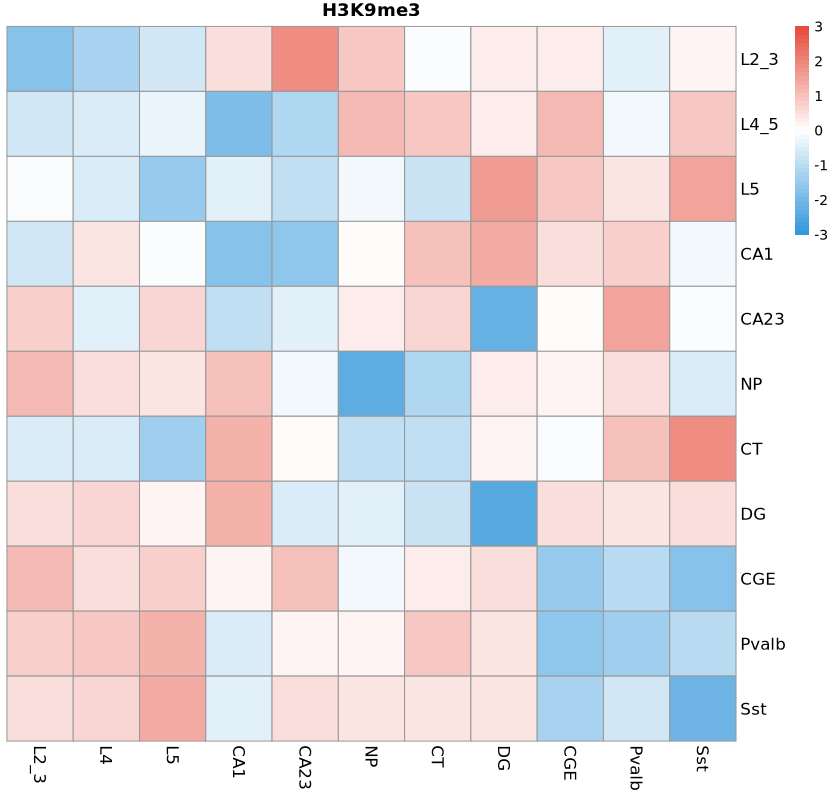

In [58]:
options(repr.plot.width = 8.4, repr.plot.height = 8, repr.plot.res = 100)
pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K9me3",
  fontsize_row = 12,
  fontsize_col = 12,
  breaks = seq(-3, 3, length.out = 51)
)

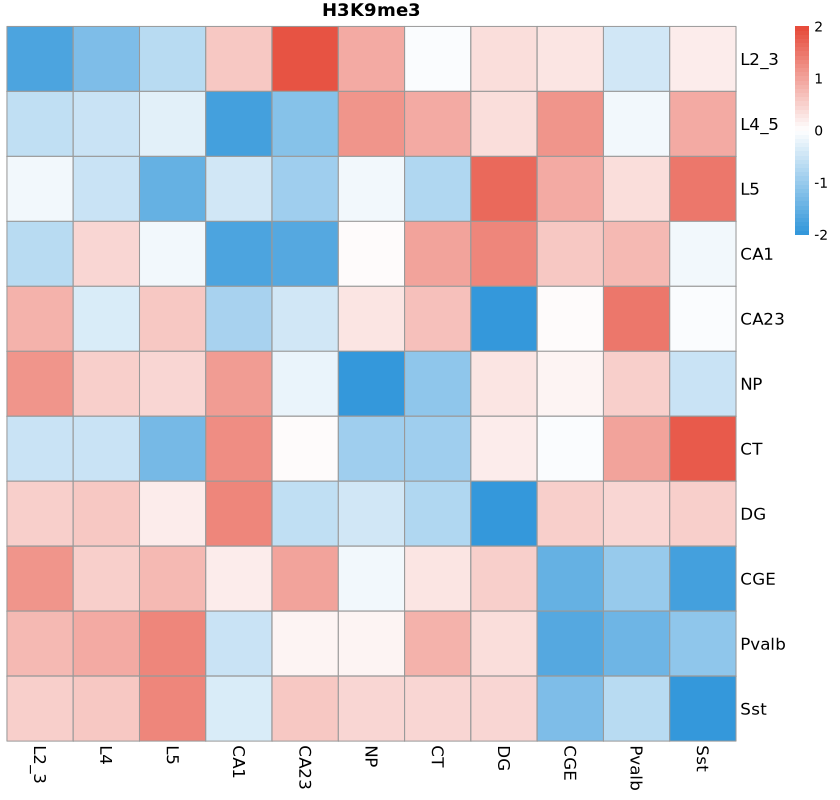

In [59]:
options(repr.plot.width = 8.4, repr.plot.height = 8, repr.plot.res = 100)
pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K9me3",
  fontsize_row = 12,
  fontsize_col = 12,
  breaks = seq(-2, 2, length.out = 51)
)

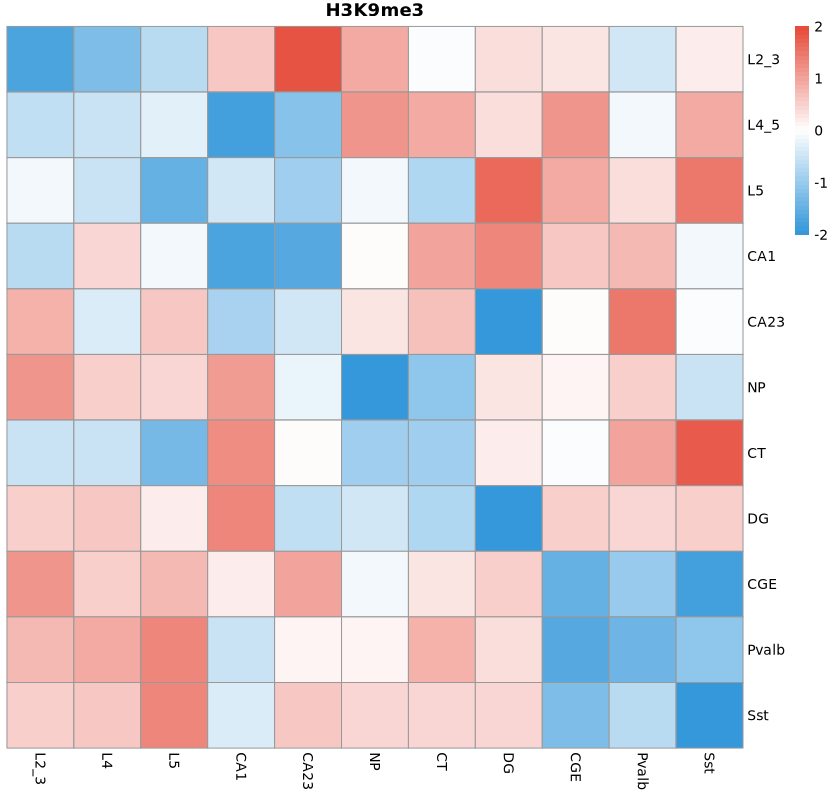

In [60]:
p1 <- pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K9me3",
  fontsize_row = 10,
  fontsize_col = 10,
  breaks = seq(-2, 2, length.out = 51)
)

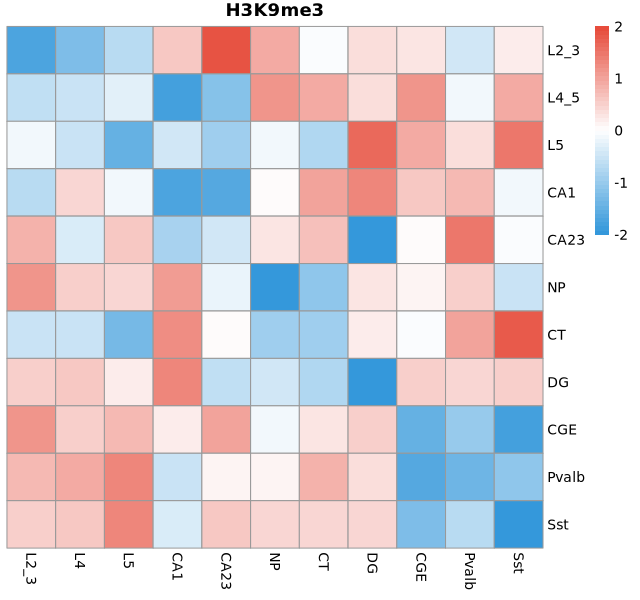

In [61]:
options(repr.plot.width = 6.4, repr.plot.height = 6, repr.plot.res = 100)
p1

In [62]:
pdf("../output/10-H3K9me3_modification_in_hyperDHMR_merge.pdf",width = 6.4,height = 6)
p1
dev.off()

png 
  2

In [ ]:
# Finished!